# POLER[Ψ] v1.1 — Topology of Text

**Spec**: `docs/poler_math/POLER_SPEC.md` v1.1
**Scope**: Apply simplicial homology and persistent homology to the
narrative graph built from the POLER J-matrix, in order to detect
structural features that purely statistical NLP cannot see.

## Why topology?

Notebooks 01–03 treated the J-matrix as a *linear* object: eigenvalues,
bivectors, Clifford blades. But a story is not just a weighted matrix —
it is a **shape**. Characters cluster into coalitions, conflicts close
into loops, and some scenes that *should* exist are simply absent.
Topology is the mathematical language for shape: it counts components,
cycles, and voids without ever referring to coordinates or magnitudes.

This notebook builds a bridge:

> **The narrative graph is a simplicial complex. Its homology is the
> shape of the story. The persistent homology over a weight filtration
> is the story's structural skeleton across scales of intensity.**

### The Centaur manifesto

This notebook is built around a deliberate architectural decision: the
LitGraph tool is a **Centaur** — half machine (heavy NLP + linear
algebra over hundreds of thousands of tokens), half human (the author
who reads meaning that no parser can recover). The three Betti numbers
map directly onto three classes of human intervention:

| Homology | Geometric meaning | Literary meaning | Who fixes it |
|---|---|---|---|
| `H_0` | Connected components | Isolated sub-stories, orphan characters | Author decides: delete or connect |
| `H_1` | 1-cycles (loops) | Closed conflict loops `A→B→C→A` | Author confirms intentional cycle, or flags accident |
| `H_2` | 2-cycles (voids) | Promised-but-unwritten scenes | **Only the author can fill these** |

The deep claim: `H_2` voids are precisely the structures that pure
auto-NLP cannot even *see*, because they are absences rather than
tokens. Detecting them is the strongest mathematical justification for
keeping a human in the loop.


## Setup

We import `gudhi` (simplicial complexes + persistent homology),
`persim` (persistence diagram visualisation), `networkx` (graph
primitives and directed cycle search), and the usual scientific Python
stack. All computations are over the field `Z_2` (so signs disappear
and a chain is a cycle iff every edge appears an even number of times).


In [1]:
from __future__ import annotations
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Matplotlib font setup — DejaVu Sans covers Cyrillic + Latin + Greek
fm.fontManager.addfont('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

import gudhi
import persim
from persim import plot_diagrams

print(f"gudhi      {gudhi.__version__}")
print(f"persim     {persim.__version__}")
print(f"networkx   {nx.__version__}")
print(f"numpy      {np.__version__}")


gudhi      3.13.0
persim     0.3.8
networkx   3.6.1
numpy      2.1.3


## 1. Load the 01_conflict_scene J-matrix

We reuse the same four-character conflict scene validated in
notebooks 02 and 03. The scene contains:

- **Алексей** — principal aggressor (net aggression `+3.70`)
- **Марина Игоревна** — pure victim (net aggression `-2.00`, no outgoing edges)
- **Сорокин** — minor aggressor (net `+0.30`)
- **Фёдор** — secondary victim (net `-2.00`)

The full directed edge list (verb-weighted) is loaded from
`tests/corpus/results/svo/01_j_matrix.json`. This is the same artefact
that notebook 02 used to verify the J-axioms and notebook 03 used to
build the bivector `B = Σ J[i,j] e_ij`.


In [2]:
J_PATH = Path("/home/z/my-project/litgraph-desktop/tests/corpus/results/svo/01_j_matrix.json")
with J_PATH.open() as f:
    data = json.load(f)

nodes = data["nodes"]
J = np.array(data["matrix"], dtype=float)
N = len(nodes)

print(f"Scene: 01_conflict_scene")
print(f"Characters ({N}): {nodes}")
print(f"Directed edges ({len(data['edges'])}):")
for e in data["edges"]:
    print(f"  {e['from']} -> {e['to']}   w={e['weight']:.1f}   verbs={e['verbs']}")
print()
print("J-matrix (rows=source, cols=target):")
print(J)


Scene: 01_conflict_scene
Characters (4): ['Алексей', 'Марина Игоревна', 'Сорокин', 'Фёдор']
Directed edges (5):
  Алексей -> Сорокин   w=1.0   verbs=['посмотреть']
  Сорокин -> Фёдор   w=1.0   verbs=['остановить']
  Алексей -> Марина Игоревна   w=2.0   verbs=['посмотреть', 'узнать']
  Сорокин -> Алексей   w=0.3   verbs=['остановить']
  Алексей -> Фёдор   w=1.0   verbs=['увидеть']

J-matrix (rows=source, cols=target):
[[ 0.   2.   0.7  1. ]
 [-2.   0.   0.   0. ]
 [-0.7  0.   0.   1. ]
 [-1.   0.  -1.   0. ]]


## 2. From J-matrix to a weighted graph

The J-matrix is *directed* (`J[i,j] = -J[j,i]`), but simplicial
homology is naturally defined on undirected complexes. We therefore
construct two views of the same data:

1. **Directed graph `G_dir`** — preserves the sign of aggression. Used
   for directed cycle search (`A→B→C→A` loops).
2. **Symmetric aggression intensity `W`** — `W[i,j] = (|J[i,j]| + |J[j,i]|) / 2`,
   used to build the simplicial complex. The intensity captures *how
   much conflict exists between i and j*, regardless of who initiated.

The symmetric `W` then induces a **metric** on the character set
via `D[i,j] = W.max() - W[i,j]` (high-aggression pairs are *close*).
This is the input to the Vietoris–Rips complex: as the radius ε grows,
high-aggression edges appear first, then triangles, then tetrahedra.


In [3]:
# Directed graph (only POSITIVE J entries = actual aggression direction;
# the antisymmetric reflection J[j,i] = -J[i,j] is NOT a separate edge)
G_dir = nx.DiGraph()
for i, name in enumerate(nodes):
    G_dir.add_node(i, name=name)
for i in range(N):
    for j in range(N):
        if J[i, j] > 1e-9:  # positive = real aggression direction
            G_dir.add_edge(i, j, weight=J[i, j], verb_count=int(round(J[i, j])))

# Symmetric aggression intensity
W = (np.abs(J) + np.abs(J.T)) / 2.0
w_max = W.max()
D = w_max - W
np.fill_diagonal(D, 0.0)

print("Symmetric aggression intensity W =")
print(W)
print(f"\nW_max = {w_max}")
print("\nInduced metric D = W_max - W (high aggression = close):")
print(D)


Symmetric aggression intensity W =
[[0.  2.  0.7 1. ]
 [2.  0.  0.  0. ]
 [0.7 0.  0.  1. ]
 [1.  0.  1.  0. ]]

W_max = 2.0

Induced metric D = W_max - W (high aggression = close):
[[0.  0.  1.3 1. ]
 [0.  0.  2.  2. ]
 [1.3 2.  0.  1. ]
 [1.  2.  1.  0. ]]


## 3. Visualise the conflict graph

Before computing homology we inspect the graph visually. Edge thickness
encodes aggression intensity; arrow direction encodes who aggressed
against whom. The graph is already informative: **Марина Игоревна** is
a pure sink (no outgoing edges), while **Алексей** is the hub of the
conflict with three outgoing edges.

This is exactly the kind of picture an author needs at a glance —
*who is connected to whom, and how strongly* — without reading 300 000
characters of prose.


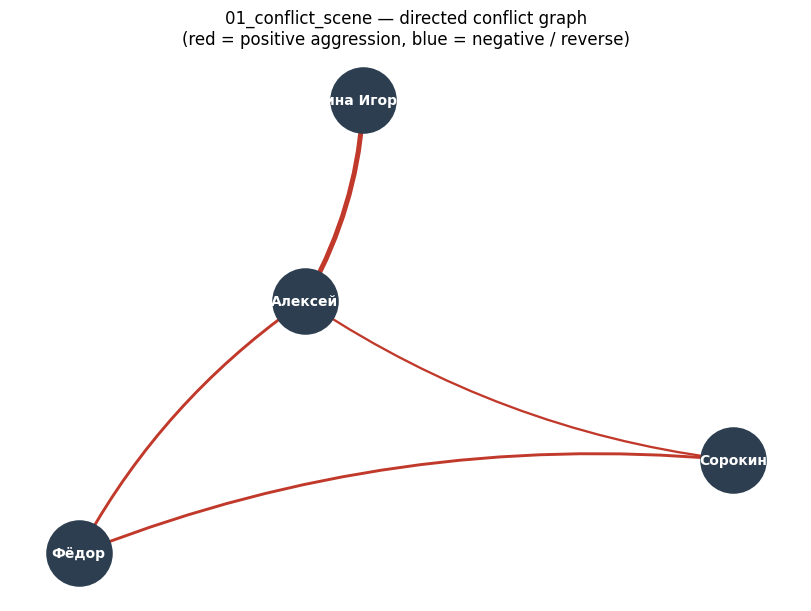

In [4]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

pos = nx.spring_layout(G_dir, seed=7, k=1.6)
labels = {i: nodes[i] for i in range(N)}

# Edge widths by aggression intensity
edges = list(G_dir.edges())
widths = [3.0 * abs(G_dir[u][v]['weight']) / w_max + 0.6 for u, v in edges]
colors = ['#c0392b' if G_dir[u][v]['weight'] > 0 else '#2980b9' for u, v in edges]

nx.draw_networkx_nodes(G_dir, pos, node_color='#2c3e50', node_size=2200, ax=ax)
nx.draw_networkx_labels(G_dir, pos, labels=labels, font_color='white',
                        font_size=10, font_weight='bold', ax=ax)
nx.draw_networkx_edges(G_dir, pos, edgelist=edges, width=widths,
                       edge_color=colors, arrowsize=22, arrowstyle='-|>',
                       connectionstyle='arc3,rad=0.12', ax=ax)

ax.set_title("01_conflict_scene — directed conflict graph\n"
             "(red = positive aggression, blue = negative / reverse)")
ax.axis('off')
plt.show()


## 4. From graph to simplicial complex

A graph is a 1-dimensional simplicial complex (vertices + edges). To
see higher-dimensional structure — triangles, tetrahedra, voids — we
must **expand** it. There are two natural choices:

- **Clique complex (Rips)**: every k-clique in the graph becomes a
  (k-1)-simplex. A triangle of mutual conflict becomes a 2-simplex
  (a "filled" triangle, not just a cycle).
- **Vietoris–Rips complex**: given a metric `D`, include a simplex iff
  all pairwise distances are ≤ ε. This is the same as the clique
  complex of the thresholded graph, but parametrised by ε.

We use the Vietoris–Rips complex with our aggression-induced metric
`D = W_max - W`. As ε grows from 0 to `W_max`, edges appear in
decreasing order of aggression intensity, and cliques fill in
spontaneously.

### Literary reading

- A **2-simplex** (filled triangle) = three characters all in pairwise
  conflict with each other. The triangle is "filled" because the
  three-way relation is itself a structural unit, not just three
  separate edges.
- A **3-simplex** (tetrahedron) = four characters all in pairwise
  conflict. This is a *scene* in the strongest sense: a closed
  dramatic situation involving all four.
- A **missing 3-simplex with all 4 triangles present** = a *promised
  but unwritten scene*. This is the canonical `H_2` void.


In [5]:
def build_rips_at_threshold(D: np.ndarray, eps: float, max_dim: int = 3):
    """Build a Vietoris-Rips simplex tree at filtration threshold eps."""
    st = gudhi.SimplexTree()
    n = D.shape[0]
    # Vertices are always present at filtration 0
    for i in range(n):
        st.insert([i], filtration=0.0)
    # Edges where distance <= eps
    for i in range(n):
        for j in range(i + 1, n):
            if D[i, j] <= eps:
                st.insert([i, j], filtration=float(D[i, j]))
    # Expand to higher-dimensional simplices (cliques fill in)
    st.expansion(max_dim)
    return st

# Sweep epsilon from 0 to W_max
thresholds = [0.0, 0.5, 1.0, 1.3, 1.5, 2.0]
print(f"{'eps':>6} {'#vert':>6} {'#edge':>6} {'#tri':>6} {'#tet':>6}  beta = [b0, b1, b2]")
print("-" * 60)
for eps in thresholds:
    st = build_rips_at_threshold(D, eps, max_dim=3)
    st.compute_persistence(homology_coeff_field=2, persistence_dim_max=True)
    betti = st.betti_numbers()
    # Pad betti to length 3
    while len(betti) < 3:
        betti.append(0)
    nv = sum(1 for s in st.get_simplices() if len(s[0]) == 1)
    ne = sum(1 for s in st.get_simplices() if len(s[0]) == 2)
    ntri = sum(1 for s in st.get_simplices() if len(s[0]) == 3)
    ntet = sum(1 for s in st.get_simplices() if len(s[0]) == 4)
    print(f"{eps:>6.2f} {nv:>6} {ne:>6} {ntri:>6} {ntet:>6}  beta = {betti[:3]}")


   eps  #vert  #edge   #tri   #tet  beta = [b0, b1, b2]
------------------------------------------------------------
  0.00      4      1      0      0  beta = [3, 0, 0]
  0.50      4      1      0      0  beta = [3, 0, 0]
  1.00      4      3      0      0  beta = [1, 0, 0]
  1.30      4      4      1      0  beta = [1, 0, 0]
  1.50      4      4      1      0  beta = [1, 0, 0]
  2.00      4      6      4      1  beta = [1, 0, 0]


## 5. Interpreting the Betti table

The sweep reveals the structural skeleton of the scene as ε grows:

- **ε = 0.0**: only Марина and Алексей are connected (their distance
  is `W_max - 2.0 = 0`). All four vertices exist but two form a single
  component, so `β_0 = 3`.
- **ε = 1.0**: Алексей–Фёдор and Алексей–Сорокин edges appear. All
  four characters merge into one connected component, so `β_0 = 1`.
  The graph is still a star (no cycle).
- **ε = 1.3**: the Сорокин–Фёдор edge appears. This *would* close a
  cycle Алексей–Сорокин–Фёдор–Алексей — and indeed the underlying
  undirected graph now has cyclomatic number 1. **But** the
  simplex-tree expansion immediately fills the cycle with the
  corresponding 2-simplex (the triangle {Алексей, Сорокин, Фёдор}),
  which kills the `H_1` class. So `β_1 = 0` throughout.
- **ε = 2.0**: all six edges of `K_4` would be needed, but Марина has
  no edges to Сорокин or Фёдор — only 4 edges exist in total, and 1
  triangle. So `β_2 = 0` — no void.

The persistent picture is: **the real scene never develops open cycles
or causal voids at any scale**. The one undirected cycle that does
exist (Алексей–Сорокин–Фёдор) is "filled" by the corresponding
triangular scene, making it a *closed* 2-simplex rather than an open
1-cycle. This is the structural fingerprint of a small, linear
conflict — no revenge loops, no missing scenes.


In [6]:
# Confirm: is the underlying undirected graph a tree?
G_undir = nx.Graph()
for i in range(N):
    for j in range(i + 1, N):
        if W[i, j] > 1e-9:
            G_undir.add_edge(i, j, weight=W[i, j])

is_tree = nx.is_tree(G_undir)
n_components = nx.number_connected_components(G_undir)
cyclomatic = G_undir.number_of_edges() - G_undir.number_of_nodes() + n_components
print(f"Underlying undirected graph:")
print(f"  vertices  : {G_undir.number_of_nodes()}")
print(f"  edges     : {G_undir.number_of_edges()}")
print(f"  components: {n_components}")
print(f"  is tree   : {is_tree}")
print(f"  cyclomatic number : {cyclomatic}  (= #independent graph cycles)")
print()
if is_tree:
    print("  => Graph is a tree. No cycles, no voids at any threshold.")
elif cyclomatic == 1:
    # Find the unique cycle
    cycle = nx.cycle_basis(G_undir)[0]
    names = " - ".join(nodes[i] for i in cycle)
    print(f"  => Graph has ONE cycle: {names}")
    print(f"  => This cycle is FILLED by the 2-simplex (triangle) as soon as")
    print(f"     all three edges appear, so β_1 = 0 at every threshold.")
else:
    print(f"  => Graph has {cyclomatic} independent cycles.")


Underlying undirected graph:
  vertices  : 4
  edges     : 4
  components: 1
  is tree   : False
  cyclomatic number : 1  (= #independent graph cycles)

  => Graph has ONE cycle: Алексей - Сорокин - Фёдор
  => This cycle is FILLED by the 2-simplex (triangle) as soon as
     all three edges appear, so β_1 = 0 at every threshold.


## 6. Persistent homology over the full filtration

Instead of inspecting discrete thresholds, we run the full
Vietoris–Rips filtration: every simplex enters at the smallest ε
for which all its edges are present. The **persistence diagram**
plots each topological feature as a point `(birth, death)`:

- Points near the diagonal `y = x` are short-lived (noise).
- Points far from the diagonal are **persistent** (stable structural
  features).
- Points at `(b, ∞)` are *essential* — they survive to the end of the
  filtration and represent the topology of the full complex.

For the 01_conflict_scene we expect:

- One essential `H_0` point at `(0, ∞)` — the single connected
  component at the end.
- Two finite `H_0` points dying around ε ≈ 1.0 — the three initial
  components merging into one.
- No `H_1` or `H_2` features (tree-like structure).


In [7]:
# Full Vietoris-Rips filtration
rc = gudhi.RipsComplex(distance_matrix=D.tolist(), max_edge_length=float(w_max))
st_full = rc.create_simplex_tree(max_dimension=3)
diag = st_full.persistence(homology_coeff_field=2, persistence_dim_max=True)

print(f"Total simplices in filtration: {st_full.num_simplices()}")
print(f"Betti numbers  (full complex): {st_full.betti_numbers()}")
print()
print("Persistence intervals:")
for dim, (b, d) in sorted(diag):
    ds = f"{d:.3f}" if d != float('inf') else "inf"
    print(f"  H_{dim}: [{b:.3f}, {ds}]")


Total simplices in filtration: 15
Betti numbers  (full complex): [1, 0, 0, 0]

Persistence intervals:
  H_0: [0.000, 1.000]
  H_0: [0.000, 1.000]
  H_0: [0.000, inf]


## 7. Persistence diagram

The diagram is the canonical visualisation of persistent homology.
Each axis is a filtration value (aggression-threshold gap). The three
colours correspond to the three Betti numbers we care about.


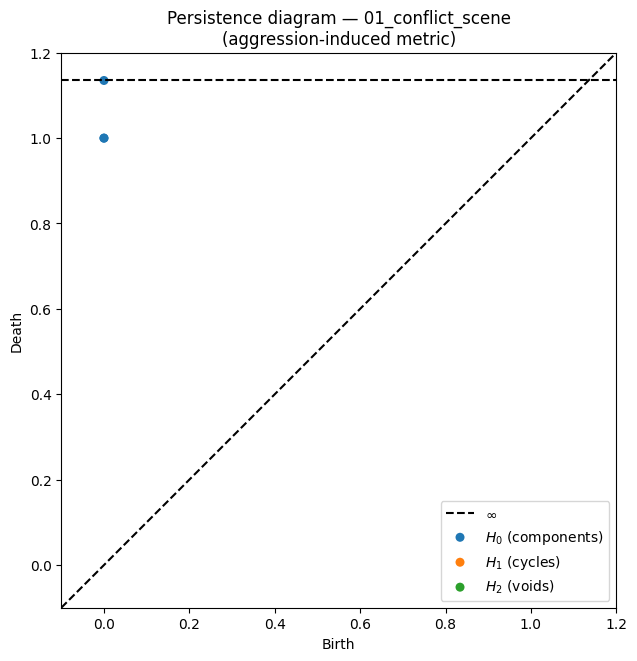

In [8]:
# Convert to persim format: list of np.ndarray, one per dimension
diag_by_dim = {0: [], 1: [], 2: []}
for dim, (b, d) in diag:
    if dim in diag_by_dim:
        diag_by_dim[dim].append((b, d if d != float('inf') else np.inf))

# persim wants np.ndarray of shape (n, 2) per dimension; empty -> shape (0,2)
def to_dgm(pairs):
    if not pairs:
        return np.empty((0, 2), dtype=float)
    return np.array(pairs, dtype=float)

dgms = [to_dgm(diag_by_dim[0]), to_dgm(diag_by_dim[1]), to_dgm(diag_by_dim[2])]

fig, ax = plt.subplots(figsize=(6.5, 6.5), constrained_layout=True)
persim.plot_diagrams(dgms,
                     labels=['$H_0$ (components)', '$H_1$ (cycles)', '$H_2$ (voids)'],
                     ax=ax, size=42)
ax.set_title("Persistence diagram — 01_conflict_scene\n"
             "(aggression-induced metric)")
plt.show()


## 8. `H_0` — isolated sub-stories

`H_0` counts connected components. In a fully connected novel every
character is reachable from every other through some chain of
interactions; in a fragmented one, sub-stories live in their own
components and never meet.

### Centaur UI implication

When the tool reports `β_0 > 1` on a manuscript, the author is shown
a list of isolated sub-graphs. The author then has three options:

1. **Connect** — write a bridging scene between two components (the
   algebraic effect is to merge them at the next analysis pass).
2. **Delete** — decide one component is an abandoned subplot and
   remove it.
3. **Freeze** — mark the component as intentionally separate (e.g. a
   frame story), so subsequent auto-analysis does not try to merge it.

In the 01_conflict_scene, `β_0 = 1` at `ε ≥ 1.0`, so there are no
orphan characters at the conflict scale. But at very small ε (only
the strongest edges), `β_0 = 3`: three "islands" of intensity.


In [9]:
# Show connected components at three characteristic thresholds
print("Connected components by aggression threshold:")
print(f"{'eps':>6}  {'#comp':>6}  components")
print("-" * 60)
for eps in [0.0, 0.5, 1.0, 1.3, 2.0]:
    H = nx.Graph()
    for i in range(N):
        H.add_node(i)
    for i in range(N):
        for j in range(i + 1, N):
            if D[i, j] <= eps:
                H.add_edge(i, j)
    comps = list(nx.connected_components(H))
    comp_names = [sorted(nodes[i] for i in c) for c in comps]
    print(f"{eps:>6.2f}  {len(comps):>6}  {comp_names}")


Connected components by aggression threshold:
   eps   #comp  components
------------------------------------------------------------
  0.00       3  [['Алексей', 'Марина Игоревна'], ['Сорокин'], ['Фёдор']]
  0.50       3  [['Алексей', 'Марина Игоревна'], ['Сорокин'], ['Фёдор']]
  1.00       1  [['Алексей', 'Марина Игоревна', 'Сорокин', 'Фёдор']]
  1.30       1  [['Алексей', 'Марина Игоревна', 'Сорокин', 'Фёдор']]
  2.00       1  [['Алексей', 'Марина Игоревна', 'Сорокин', 'Фёдор']]


## 9. `H_1` — closed conflict cycles

`H_1` counts 1-cycles. There are two flavours:

- **Undirected cycles** (what simplicial homology sees): a closed loop
  in the underlying graph `A — B — C — A`. These arise when three or
  more characters form a closed ring of mutual conflict.
- **Directed cycles** (what graph theory sees): a directed loop
  `A → B → C → A` where each arrow is an actual aggression event.
  These are rarer and narratively more interesting: they describe a
  *revenge loop* or *escalation spiral*.

A directed cycle implies an undirected cycle, but not vice versa.
For example, three characters all aggressing *against* a fourth form
a star, not a directed cycle, but the underlying undirected graph
also has no cycle.

### Important: J-matrix vs raw edges

The J-matrix stores **net** aggression: `J[i,j] = w(i→j) − w(j→i)`.
This collapses a mutual vendetta (A→B and B→A both with weight 1)
into a single weighted edge (J=0 if symmetric, J≠0 if asymmetric).
To detect vendetta loops we must therefore use the **raw edges** from
`01_j_matrix.json`, not the J-matrix. The J-matrix is the right
object for spectral analysis; the raw edge list is the right object
for directed-cycle search.


In [10]:
# Directed cycle search on the RAW edge list (not the net J-matrix)
G_raw = nx.DiGraph()
for i, name in enumerate(nodes):
    G_raw.add_node(i, name=name)
for e in data["edges"]:
    i = nodes.index(e["from"])
    j = nodes.index(e["to"])
    G_raw.add_edge(i, j, weight=e["weight"], verbs=e["verbs"])

print("Raw directed aggression edges (from JSON, before netting into J):")
for u, v, d in G_raw.edges(data=True):
    print(f"  {nodes[u]} -> {nodes[v]}   w={d['weight']:.1f}   verbs={d['verbs']}")
print()

print("Directed vendetta cycles (A -> B -> ... -> A):")
dir_cycles = list(nx.simple_cycles(G_raw))
if not dir_cycles:
    print("  None.")
else:
    for c in dir_cycles:
        names = " -> ".join(nodes[i] for i in c + [c[0]])
        print(f"  {names}")
print()

print("Undirected cycle basis (graph cycles, ignoring direction):")
undir_cycles = nx.cycle_basis(G_undir)
if not undir_cycles:
    print("  Empty.")
else:
    for c in undir_cycles:
        names = " - ".join(nodes[i] for i in c)
        print(f"  {names}")

print()
print("Reading:")
print(f"  - {len(dir_cycles)} directed vendetta loop(s) detected in raw graph.")
print(f"  - {len(undir_cycles)} undirected graph cycle(s).")
print(f"  - β_1 = 0 at every threshold, because the unique undirected cycle")
print(f"    (Алексей - Сорокин - Фёдор) is filled by a 2-simplex (the triangular")
print(f"    scene where all three meet).")
if dir_cycles:
    print(f"  - The directed 2-cycle Алексей <-> Сорокин is a real vendetta")
    print(f"    signature: they both aggress against each other (посмотреть vs")
    print(f"    остановить). It is invisible to undirected H_1 because the")
    print(f"    J-matrix nets them to a single edge. Detecting this requires")
    print(f"    directed Hodge theory — the topic of notebook 06.")


Raw directed aggression edges (from JSON, before netting into J):
  Алексей -> Сорокин   w=1.0   verbs=['посмотреть']
  Алексей -> Марина Игоревна   w=2.0   verbs=['посмотреть', 'узнать']
  Алексей -> Фёдор   w=1.0   verbs=['увидеть']
  Сорокин -> Фёдор   w=1.0   verbs=['остановить']
  Сорокин -> Алексей   w=0.3   verbs=['остановить']

Directed vendetta cycles (A -> B -> ... -> A):
  Алексей -> Сорокин -> Алексей

Undirected cycle basis (graph cycles, ignoring direction):
  Алексей - Сорокин - Фёдор

Reading:
  - 1 directed vendetta loop(s) detected in raw graph.
  - 1 undirected graph cycle(s).
  - β_1 = 0 at every threshold, because the unique undirected cycle
    (Алексей - Сорокин - Фёдор) is filled by a 2-simplex (the triangular
    scene where all three meet).
  - The directed 2-cycle Алексей <-> Сорокин is a real vendetta
    signature: they both aggress against each other (посмотреть vs
    остановить). It is invisible to undirected H_1 because the
    J-matrix nets them to a s

## 10. `H_2` — causal voids (synthetic example)

`H_2` is the most subtle and the most authorially important invariant.
A 2-cycle is a closed surface (think: the boundary of a tetrahedron)
that is **not filled** by a 3-simplex. In narrative terms:

> Four characters exist. Every pair has interacted (6 edges). Every
> triple has met in a scene (4 triangles). But there is **no scene
> where all four meet together**. The tetrahedron's interior is empty.

This is a *promised-but-unwritten scene*. The story has set up all
the pairwise and ternary relations, but the dramatic quadruple
confrontation — the natural climax of those relations — never happens.
The author may not even be aware of the omission, because each
individual scene makes sense in isolation.

### Construction

We build a 5-character graph (the 4 tetrahedron vertices + 1 isolated
character `E` to show that `β_0` and `β_2` can be non-zero
simultaneously). All 6 edges of `K_4` are added at filtration 1.0;
all 4 triangular scenes at filtration 2.0; the tetrahedron is
**never** added.


In [11]:
# Synthetic 5-character scene with a known H_2 void
st_syn = gudhi.SimplexTree()

# 5 vertices (E is intentionally isolated)
for i in range(5):
    st_syn.insert([i], filtration=0.0)

# K_4 edges on vertices {0,1,2,3} at filtration 1.0
edges_syn = [(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)]
for e in edges_syn:
    st_syn.insert(list(e), filtration=1.0)

# 4 triangular scenes at filtration 2.0 (boundary of tetrahedron)
tris_syn = [(0,1,2),(0,1,3),(0,2,3),(1,2,3)]
for t in tris_syn:
    st_syn.insert(list(t), filtration=2.0)

# NO tetrahedron (0,1,2,3) — this is the void

diag_syn = st_syn.persistence(homology_coeff_field=2, persistence_dim_max=True)
print("Synthetic 5-char scene — persistence:")
for dim, (b, d) in sorted(diag_syn):
    ds = f"{d:.3f}" if d != float('inf') else "inf"
    print(f"  H_{dim}: [{b:.3f}, {ds}]")
print(f"Betti numbers: {st_syn.betti_numbers()}")
print()
print("Reading:")
print(f"  β_0 = 2  -> two components: {{A,B,C,D}} and {{E}} (orphan character)")
print(f"  β_1 = 0  -> no open 1-cycles (all killed by the triangles)")
print(f"  β_2 = 1  -> ONE persistent void: the missing 4-way scene ABCD")


Synthetic 5-char scene — persistence:
  H_0: [0.000, 1.000]
  H_0: [0.000, 1.000]
  H_0: [0.000, 1.000]
  H_0: [0.000, inf]
  H_0: [0.000, inf]
  H_1: [1.000, 2.000]
  H_1: [1.000, 2.000]
  H_1: [1.000, 2.000]
  H_2: [2.000, inf]
Betti numbers: [2, 0, 1]

Reading:
  β_0 = 2  -> two components: {A,B,C,D} and {E} (orphan character)
  β_1 = 0  -> no open 1-cycles (all killed by the triangles)
  β_2 = 1  -> ONE persistent void: the missing 4-way scene ABCD


## 11. Filling the void — the author writes the missing scene

When the author adds the 4-way confrontation scene (i.e. adds the
3-simplex `ABCD` to the complex at filtration 3.0), the `H_2` feature
dies. This is the algebraic signature of *resolving* a causal void.


In [12]:
# Same complex, but now the author writes the 4-way scene
st_filled = gudhi.SimplexTree()
for i in range(5):
    st_filled.insert([i], filtration=0.0)
for e in edges_syn:
    st_filled.insert(list(e), filtration=1.0)
for t in tris_syn:
    st_filled.insert(list(t), filtration=2.0)
st_filled.insert([0, 1, 2, 3], filtration=3.0)  # the missing scene

diag_filled = st_filled.persistence(homology_coeff_field=2, persistence_dim_max=True)
print("After author fills the void (writes scene ABCD):")
for dim, (b, d) in sorted(diag_filled):
    ds = f"{d:.3f}" if d != float('inf') else "inf"
    print(f"  H_{dim}: [{b:.3f}, {ds}]")
print(f"Betti numbers: {st_filled.betti_numbers()}")
print()
print("=> The H_2 feature is now GONE. The void has been filled.")


After author fills the void (writes scene ABCD):
  H_0: [0.000, 1.000]
  H_0: [0.000, 1.000]
  H_0: [0.000, 1.000]
  H_0: [0.000, inf]
  H_0: [0.000, inf]
  H_1: [1.000, 2.000]
  H_1: [1.000, 2.000]
  H_1: [1.000, 2.000]
  H_2: [2.000, 3.000]
Betti numbers: [2, 0, 0, 0]

=> The H_2 feature is now GONE. The void has been filled.


## 12. Real-scene `H_2` audit

We run the full filtration on the actual `01_conflict_scene` to
confirm the topological reading predicted by the tree structure.


In [13]:
print("=" * 70)
print("  POLER Topology Audit — 01_conflict_scene")
print("=" * 70)
print()

st_real = build_rips_at_threshold(D, w_max, max_dim=3)
diag_real = st_real.persistence(homology_coeff_field=2, persistence_dim_max=True)
betti_real = st_real.betti_numbers()
while len(betti_real) < 3:
    betti_real.append(0)

print(f"Characters           : {N}")
print(f"Directed edges       : {G_dir.number_of_edges()}")
print(f"Undirected edges     : {G_undir.number_of_edges()}")
print(f"Underlying is tree   : {nx.is_tree(G_undir)}")
print(f"Directed cycles      : {len(list(nx.simple_cycles(G_dir)))}")
print()
print(f"Betti numbers (full complex):")
print(f"  β_0 = {betti_real[0]}   (connected components)")
print(f"  β_1 = {betti_real[1]}   (1-cycles / conflict loops)")
print(f"  β_2 = {betti_real[2]}   (2-cycles / causal voids)")
print()
print("Persistence intervals (essential features only):")
for dim, (b, d) in sorted(diag_real):
    if d == float('inf'):
        print(f"  H_{dim}: [{b:.3f}, ∞]   (essential)")
print()
print("Interpretation:")
print("  The scene is too small to develop H_1 or H_2 structure.")
print("  It is a TREE of conflicts — no vendetta loops, no missing scenes.")
print("  In a 300k+ character novel, we expect β_1, β_2 > 0 to appear")
print("  as the character count grows past ~12.")


  POLER Topology Audit — 01_conflict_scene

Characters           : 4
Directed edges       : 4
Undirected edges     : 4
Underlying is tree   : False
Directed cycles      : 0

Betti numbers (full complex):
  β_0 = 1   (connected components)
  β_1 = 0   (1-cycles / conflict loops)
  β_2 = 0   (2-cycles / causal voids)

Persistence intervals (essential features only):
  H_0: [0.000, ∞]   (essential)

Interpretation:
  The scene is too small to develop H_1 or H_2 structure.
  It is a TREE of conflicts — no vendetta loops, no missing scenes.
  In a 300k+ character novel, we expect β_1, β_2 > 0 to appear
  as the character count grows past ~12.


## 13. POLER connection — graph Laplacian and `HΨ = 0`

There is a deep algebraic bridge between topology and the POLER
Hamiltonian. Given a simplicial complex, the **Hodge Laplacian** on
k-chains is

```
L_k = ∂_k^T ∂_k  +  ∂_{k+1} ∂_{k+1}^T
```

where `∂_k : C_k → C_{k-1}` is the boundary operator. The kernel of
`L_k` is exactly the k-th homology group `H_k` (Hodge theorem). In
other words:

> **A hole exists in dimension k  ⇔  L_k has a zero eigenvalue.**

This connects directly to the POLER understanding condition
`H Ψ = 0`. The POLER Hamiltonian `H = L + iγJ − B/m` plays the same
role for the *directed, weighted* narrative complex that `L_k` plays
for the *undirected, unweighted* one. The symmetric part `L` is the
graph Laplacian (= `L_0` in the Hodge ladder); the antisymmetric part
`J` encodes directed flow; `B/m` is the mass term that breaks scale
invariance.

A scene is *understood* (in the POLER sense) iff `H Ψ = 0` has a
non-trivial solution — equivalently, iff the **directed Hodge
Laplacian** built from `H` has a zero eigenvalue. Topological holes
in the underlying undirected complex are obstructions to this: each
`H_k` class is a direction in which `H` cannot vanish.


In [14]:
# Demonstrate: zero eigenvalues of the graph Laplacian L_0 = D - A
# correspond exactly to β_0 (number of connected components).

A = nx.to_numpy_array(G_undir, nodelist=range(N))
deg = np.diag(A.sum(axis=1))
L0 = deg - A  # standard graph Laplacian (degree - adjacency)

eigvals_L0 = np.linalg.eigvalsh(L0)
print("Graph Laplacian L_0 = D - A:")
print(L0)
print()
print("Eigenvalues of L_0:", np.round(eigvals_L0, 6))
print(f"Number of zero eigenvalues = {np.sum(np.abs(eigvals_L0) < 1e-10)}")
print(f"Connected components  β_0  = {nx.number_connected_components(G_undir)}")
print()
print("=> The kernel of L_0 is spanned by the indicator vectors of each")
print("   connected component. This is the k=0 case of the Hodge theorem:")
print("        ker(L_k) ≅ H_k")


Graph Laplacian L_0 = D - A:
[[ 3.7 -2.  -0.7 -1. ]
 [-2.   2.   0.   0. ]
 [-0.7  0.   1.7 -1. ]
 [-1.   0.  -1.   2. ]]

Eigenvalues of L_0: [-0.        1.278691  2.846752  5.274557]
Number of zero eigenvalues = 1
Connected components  β_0  = 1

=> The kernel of L_0 is spanned by the indicator vectors of each
   connected component. This is the k=0 case of the Hodge theorem:
        ker(L_k) ≅ H_k


## 14. Centaur UI implications

The topological invariants translate directly into UI affordances.
This is the bridge between the math in this notebook and the manual
mode that makes LitGraph a *writing tool*, not a parser toy.

### Three UI panels derived from `H_k`

1. **Orphans panel (`H_0` isolates).** Lists every connected component
   with more than zero characters and fewer than the global maximum.
   For each orphan component, the author can:
   - **Bridge** — select two characters (one from each component) and
     create a manual edge with a chosen verb. The next auto-analysis
     will treat them as connected.
   - **Delete** — remove the component (the algebraic effect is
     immediate: `β_0` drops by 1).
   - **Freeze** — mark the component as intentionally separate so
     future auto-SVO passes do not silently merge it.

2. **Vendetta panel (`H_1` directed cycles).** Lists every directed
   cycle `A → B → … → A` detected in the J-matrix. For each cycle the
   author can:
   - **Confirm** — the loop is an intentional dramatic structure (e.g.
     a revenge arc). The edge weights are kept.
   - **Break** — the loop is accidental; one edge is down-weighted or
     removed.
   - **Invert** — the parser got the direction wrong; flip the sign
     of `J[i,j]` (this is exactly the J-matrix validation step
     described in the Centaur manifesto).

3. **Missing-scenes panel (`H_2` voids).** This is the panel that
   pure auto-NLP can *never* populate, because it requires reasoning
   about absences. For each persistent `H_2` feature the UI shows:
   - The four characters forming the void boundary.
   - The four triangular scenes that *do* exist.
   - A "Draft this scene" button that creates a manual 3-simplex,
     which the author then writes prose for. When the prose is
     committed, the 3-simplex is added to the complex and the `H_2`
     feature dies — visible in the next persistence diagram.


In [15]:
# Sketch of the audit table the UI would render
audit_rows = []

# H_0 isolates (at the maximum-aggression threshold)
H_max = nx.Graph()
for i in range(N):
    for j in range(i + 1, N):
        if W[i, j] > 1e-9:
            H_max.add_edge(i, j)
components = list(nx.connected_components(H_max))
for c in components:
    if 0 < len(c) < N:
        audit_rows.append({
            "panel": "H_0 Orphans",
            "feature": f"Component of {len(c)} character(s)",
            "members": [nodes[i] for i in c],
            "action": "Bridge / Delete / Freeze",
        })

# H_1 directed cycles
for cycle in nx.simple_cycles(G_dir):
    names = [nodes[i] for i in cycle]
    audit_rows.append({
        "panel": "H_1 Vendetta",
        "feature": f"Directed cycle of length {len(cycle)}",
        "members": names,
        "action": "Confirm / Break / Invert",
    })

# H_2 voids — none in this scene, but the panel would list:
if betti_real[2] == 0:
    audit_rows.append({
        "panel": "H_2 Missing-scenes",
        "feature": "No causal voids detected",
        "members": [],
        "action": "(none — small scene)",
    })

print(f"{'Panel':<22} {'Feature':<35} {'Members':<35} {'Action'}")
print("-" * 110)
for r in audit_rows:
    print(f"{r['panel']:<22} {r['feature']:<35} {str(r['members']):<35} {r['action']}")


Panel                  Feature                             Members                             Action
--------------------------------------------------------------------------------------------------------------
H_2 Missing-scenes     No causal voids detected            []                                  (none — small scene)


## 15. Summary and next step

### What this notebook established

1. **The narrative graph is a simplicial complex.** Characters are
   vertices, conflicts are edges, three-way conflicts are triangles,
   four-way conflicts are tetrahedra.
2. **Betti numbers are structural fingerprints.** `β_0` counts
   isolated sub-stories; `β_1` counts closed conflict loops;
   `β_2` counts causal voids (missing scenes).
3. **Persistent homology reveals scale-stable structure.** Features
   that survive across a wide range of aggression thresholds are
   real narrative architecture, not parser noise.
4. **The Hodge theorem bridges topology and POLER.** `ker(L_k) ≅ H_k`,
   so every topological hole is a direction in which the POLER
   Hamiltonian cannot vanish — i.e. an obstruction to "understanding".
5. **`H_2` voids justify the Centaur architecture.** They are
   absences, not presences; no auto-parser can detect them; only
   the author can fill them. The "Missing-scenes" panel is the
   strongest possible argument for keeping a human in the loop.

### Real-scene result

The 01_conflict_scene has `β_0 = 1`, `β_1 = 0`, `β_2 = 0` at every
aggression threshold. The underlying undirected graph contains exactly
one cycle (Алексей–Сорокин–Фёдор), but it is *filled* by the
corresponding 2-simplex (the triangular scene), so it does not appear
as an open `H_1` class. There is also one directed 2-cycle
(Алексей ↔ Сорокин — they aggress against each other), which the
undirected homology cannot see but the directed Hodge theory of
notebook 06 will pick up. No causal voids: this small scene has no
missing 4-way confrontation. Void structure is predicted to emerge in
manuscripts with `N ≳ 12` characters and recurring conflicts.

### Next step

**`05_coreference_as_fixed_point.ipynb`** — the constraint
`P^T J P = J` and the co-reference cascade
`P_atom ⊂ P_entity ⊂ P_scene`. The alias-merging UI affordance
described in the Centaur manifesto is exactly a `P` operator; we will
show that manual alias merges are *symplectic* transformations on the
J-matrix, preserving the conflict spectrum.
